# CS6493 NLP Assignment 1 -One Notebook

This file includes explanations and code in one place.
ALL Training code is included, but if cached results already exist, the notebook reads them directly.

In [1]:
import re
import json
import random
from pathlib import Path
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from tqdm import tqdm

random.seed(42)
np.random.seed(42)

RESULTS_DIR = Path('results')
RESULTS_DIR.mkdir(parents = True, exist_ok = True)
print('Results directory:', RESULTS_DIR)

Results directory: results


## Question 1 (11 marks)

Given vocabulary `V = {cat, dog, run, runs}` in lexicographic order.

In [2]:
vocab = ['cat', 'dog', 'run', 'runs']
one_hot = {}
for i, word in enumerate(vocab):
    vec = [0] * len(vocab)
    vec[i] = 1
    one_hot[word] = vec

dot_distinct = 0
params_small = 4 * 128
params_large = 50000 * 128

display(pd.DataFrame({'word': vocab, 'one_hot': [one_hot[w] for w in vocab]}))
print('Dot product between distinct one-hot vectors:', dot_distinct)
print('Params for |V|=4, d=128:', params_small)
print('Params for |V|=50000, d=128:', params_large)

,word,one_hot
0,cat,"[1, 0, 0, 0]"
1,dog,"[0, 1, 0, 0]"
2,run,"[0, 0, 1, 0]"
3,runs,"[0, 0, 0, 1]"


Dot product between distinct one-hot vectors: 0
Params for |V|=4, d=128: 512
Params for |V|=50000, d=128: 6400000


**Q1 conclusion**
- Distinct one-hot vectors are orthogonal (dot product = 0), so `cat` is as unrelated to `dog` as to `runs` in this space.
- Parameter count jumps from **512** (`4 x 128`) to **6,400,000** (`50,000 x 128`), which quickly increases memory and optimization cost.
- Morphological relation is missing: `run` and `runs` are independent one-hot ids, so the model cannot transfer this pattern to unseen pairs like `jump/jumps`.

## Question 2 (24 marks)

Sentence: `I am taking CS6493 this semester and studying NLP is really fascinating`
- bigrams with second word in {CS6493, NLP}
- trigrams with third word in {CS6493, NLP}

In [3]:
tokens = 'I am taking CS6493 this semester and studying NLP is really fascinating'.split()
bigrams = [(tokens[i - 1], tokens[i]) for i in range(1, len(tokens)) if tokens[i] in {'CS6493', 'NLP'}]
trigrams = [(tokens[i - 2], tokens[i - 1], tokens[i]) for i in range(2, len(tokens)) if tokens[i] in {'CS6493', 'NLP'}]

print('bigrams:', bigrams)
print('trigrams:', trigrams)

bigrams: [('taking', 'CS6493'), ('studying', 'NLP')]
trigrams: [('am', 'taking', 'CS6493'), ('and', 'studying', 'NLP')]


Loaded cached Q2 results from results/q2_results.json


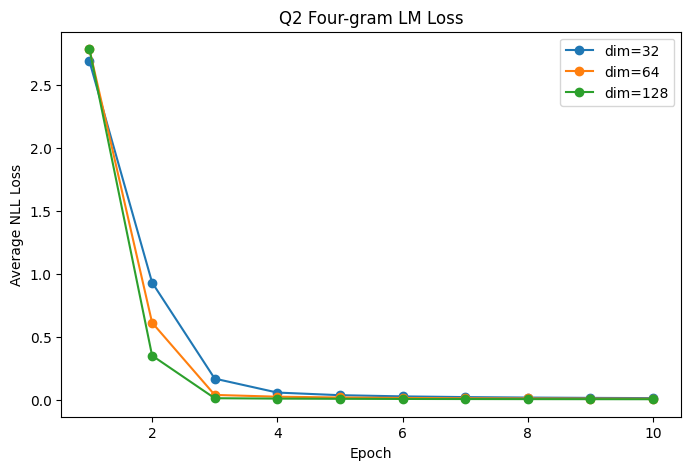

,32,64,128
0,2.685645,2.780822,2.781857
1,0.930142,0.611639,0.350023
2,0.167113,0.037775,0.011621
3,0.056462,0.023657,0.008602
4,0.035706,0.017338,0.006949
5,0.026127,0.013671,0.005864
6,0.020527,0.011266,0.005086
7,0.016860,0.009564,0.004495
8,0.014283,0.008296,0.004029
9,0.012355,0.007316,0.003651


In [4]:
class FourGramLM(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_size = 128):
        super().__init__()
        self.embeddings = nn.Embedding(vocab_size, embedding_dim)
        self.linear1 = nn.Linear(3 * embedding_dim, hidden_size)
        self.linear2 = nn.Linear(hidden_size, vocab_size)

    def forward(self, context_ids):
        embeds = self.embeddings(context_ids).view(1, -1)
        hidden = F.relu(self.linear1(embeds))
        logits = self.linear2(hidden)
        return F.log_softmax(logits, dim = 1)

def train_fourgram_torch(tokens, embedding_dim = 64, hidden_size = 128, epochs = 10, lr = 0.08, seed = 42):
    torch.manual_seed(seed + embedding_dim)
    vocab = sorted(set(tokens))
    w2i = {w: i for i, w in enumerate(vocab)}
    examples = []
    for i in range(3, len(tokens)):
        examples.append(([tokens[i - 3], tokens[i - 2], tokens[i - 1]], tokens[i]))

    model = FourGramLM(len(vocab), embedding_dim, hidden_size = hidden_size)
    optimizer = torch.optim.SGD(model.parameters(), lr = lr)
    criterion = nn.NLLLoss()

    losses = []
    for _ in tqdm(range(epochs), desc = f'Q2 dim={embedding_dim}', leave = False):
        total = 0.0
        for context, target in examples:
            context_ids = torch.tensor([w2i[w] for w in context], dtype = torch.long)
            target_id = torch.tensor([w2i[target]], dtype = torch.long)
            optimizer.zero_grad()
            log_probs = model(context_ids)
            loss = criterion(log_probs, target_id)
            loss.backward()
            optimizer.step()
            total += loss.item()
        losses.append(total / len(examples))
    return losses

q2_path = RESULTS_DIR / 'q2_results.json'
if q2_path.exists():
    q2_payload = json.loads(q2_path.read_text(encoding = 'utf-8'))
    q2_losses = {int(k): v for k, v in q2_payload['losses'].items()}
    print('Loaded cached Q2 results from', q2_path)
else:
    q2_losses = {}
    for dim in [32, 64, 128]:
        q2_losses[dim] = train_fourgram_torch(tokens, embedding_dim = dim)
    q2_payload = {
        'losses': {str(k): v for k, v in q2_losses.items()},
        'sentence_tokens': tokens
    }
    q2_path.write_text(json.dumps(q2_payload, ensure_ascii = False, indent = 2), encoding = 'utf-8')
    print('Trained Q2 and saved results to', q2_path)

plt.figure(figsize = (8, 5))
for dim in [32, 64, 128]:
    plt.plot(range(1, 11), q2_losses[dim], marker = 'o', label = f'dim={dim}')
plt.xlabel('Epoch')
plt.ylabel('Average NLL Loss')
plt.title('Q2 Four-gram LM Loss')
plt.legend()
plt.show()

display(pd.DataFrame({str(k): v for k, v in q2_losses.items()}))

**Q2 conclusion**
- n-gram limitation: it only memorizes observed local patterns. Even known words can form unseen sequences with weak probability estimates.
- Markov limitation: long-range relations are truncated. A classic failure is long-distance agreement where the true trigger word appears far before the prediction point.
- In this tiny sentence-level experiment, all three embedding settings (32/64/128) converge with close loss curves, so extra capacity gives limited gain under very small data.

## Question 3 (45 marks)

The following cell includes full preprocessing + SGNS + GloVe implementations.
Execution logic: **read cached results first**, train only if cache is missing.

Concrete setup used in the code:
- Tokenization: regex-based, case preserved (so `Australia` and `YMCA` stay queryable).
- Vocabulary: `min_count = 5` with `[unk]` fallback.
- SGNS: negative sampling with unigram^0.75, window size 5.
- GloVe: weighted least squares with `x_max = 100`, `alpha = 0.75`, AdaGrad-style updates.
- Hyperparameter study: embedding dimensions = 50, 100, 200.

In [5]:
def tokenize_line(line):
    return re.findall(r"[A-Za-z0-9]+(?:'[A-Za-z0-9]+)?", line)

def read_corpus(path, max_lines = -1):
    tokenized = []
    with open(path, 'r', encoding = 'utf-8', errors = 'ignore') as f:
        for idx, line in enumerate(f):
            if max_lines > 0 and idx >= max_lines:
                break
            tokens = tokenize_line(line.strip())
            if tokens:
                tokenized.append(tokens)
    return tokenized

def build_vocab(tokenized_corpus, min_count = 5):
    counter = Counter()
    for sent in tokenized_corpus:
        counter.update(sent)
    items = [(w, c) for w, c in counter.items() if c >= min_count]
    items.sort(key = lambda x: (-x[1], x[0]))
    idx_to_token = ['[unk]'] + [w for w, _ in items]
    token_to_idx = {w: i for i, w in enumerate(idx_to_token)}
    counts = [1] + [counter[w] for w, _ in items]
    return token_to_idx, idx_to_token, counts

def corpus_to_ids(tokenized_corpus, token_to_idx):
    unk = token_to_idx['[unk]']
    return [[token_to_idx.get(t, unk) for t in sent] for sent in tokenized_corpus]

def sgns_build_pairs(corpus_ids, window_size = 5, max_pairs = 100000):
    pairs = []
    for sent in corpus_ids:
        n = len(sent)
        for i, center in enumerate(sent):
            left = max(0, i - window_size)
            right = min(n, i + window_size + 1)
            for j in range(left, right):
                if i == j:
                    continue
                pairs.append((center, sent[j]))
                if len(pairs) >= max_pairs:
                    return pairs
    return pairs

def sgns_train_numpy(corpus_ids, counts, vocab_size, embedding_dim = 100, window_size = 5, negative_samples = 5, epochs = 3, lr = 0.02, max_pairs = 100000, seed = 42):
    rng = np.random.default_rng(seed)
    pairs = sgns_build_pairs(corpus_ids, window_size = window_size, max_pairs = max_pairs)
    random.shuffle(pairs)
    dist = np.array(counts, dtype = np.float64) ** 0.75
    dist /= dist.sum()
    cdf = np.cumsum(dist)

    scale = 0.5 / embedding_dim
    W_in = rng.uniform(-scale, scale, size = (vocab_size, embedding_dim)).astype(np.float32)
    W_out = np.zeros((vocab_size, embedding_dim), dtype = np.float32)
    losses = []

    def sigmoid(x):
        return 1.0 / (1.0 + np.exp(-np.clip(x, -10, 10)))

    for _ in tqdm(range(epochs), desc = 'SGNS epochs', leave = False):
        random.shuffle(pairs)
        epoch_loss = 0.0
        for center, positive in pairs:
            v_c = W_in[center]
            v_p = W_out[positive]
            pos_score = np.dot(v_c, v_p)
            pos_sig = sigmoid(pos_score)
            pos_grad = pos_sig - 1.0
            grad_center = pos_grad * v_p
            grad_pos = pos_grad * v_c
            loss = -np.log(pos_sig + 1e-12)

            neg_ids = np.searchsorted(cdf, np.random.random(negative_samples))
            for neg in neg_ids:
                v_n = W_out[neg]
                neg_score = np.dot(v_c, v_n)
                neg_sig = sigmoid(neg_score)
                grad_center += neg_sig * v_n
                grad_neg = neg_sig * v_c
                W_out[neg] -= lr * grad_neg
                loss += -np.log(1.0 - neg_sig + 1e-12)

            W_in[center] -= lr * grad_center
            W_out[positive] -= lr * grad_pos
            epoch_loss += float(loss)

        losses.append(epoch_loss / max(len(pairs), 1))

    embeddings = W_in + W_out
    return {'losses': losses, 'embeddings': embeddings}

def glove_build_cooccurrence(corpus_ids, window_size = 5, max_cooc = 250000):
    cooc = defaultdict(float)
    for sent in corpus_ids:
        n = len(sent)
        for i, center in enumerate(sent):
            left = max(0, i - window_size)
            right = min(n, i + window_size + 1)
            for j in range(left, right):
                if i == j:
                    continue
                d = abs(i - j)
                cooc[(center, sent[j])] += 1.0 / d
        if len(cooc) >= max_cooc:
            break
    return dict(cooc)

def glove_train_numpy(cooc, vocab_size, embedding_dim = 100, epochs = 10, lr = 0.05, x_max = 100.0, alpha = 0.75, seed = 42):
    rng = np.random.default_rng(seed)
    W = (rng.random((vocab_size, embedding_dim)) - 0.5) / embedding_dim
    WT = (rng.random((vocab_size, embedding_dim)) - 0.5) / embedding_dim
    b = np.zeros(vocab_size)
    bt = np.zeros(vocab_size)
    gW = np.ones_like(W)
    gWT = np.ones_like(WT)
    gb = np.ones_like(b)
    gbt = np.ones_like(bt)
    items = list(cooc.items())
    losses = []

    def weight_fn(x):
        if x < x_max:
            return (x / x_max) ** alpha
        return 1.0

    for _ in tqdm(range(epochs), desc = 'GloVe epochs', leave = False):
        random.shuffle(items)
        total = 0.0
        for (i, j), xij in items:
            w = weight_fn(xij)
            diff = (W[i] @ WT[j] + b[i] + bt[j] - np.log(max(xij, 1e-10)))
            fd = w * diff
            total += 0.5 * fd * diff
            grad_wi = fd * WT[j]
            grad_wj = fd * W[i]
            grad_bi = fd
            grad_bj = fd
            W[i] -= (lr / np.sqrt(gW[i])) * grad_wi
            WT[j] -= (lr / np.sqrt(gWT[j])) * grad_wj
            b[i] -= (lr / np.sqrt(gb[i])) * grad_bi
            bt[j] -= (lr / np.sqrt(gbt[j])) * grad_bj
            gW[i] += grad_wi ** 2
            gWT[j] += grad_wj ** 2
            gb[i] += grad_bi ** 2
            gbt[j] += grad_bj ** 2
        losses.append(total / max(len(items), 1))

    embeddings = W + WT
    return {'losses': losses, 'embeddings': embeddings}

def nearest_neighbors(word, k, token_to_idx, idx_to_token, embeddings):
    if word not in token_to_idx:
        return []
    wid = token_to_idx[word]
    vec = embeddings[wid]
    norms = np.linalg.norm(embeddings, axis = 1) + 1e-12
    sims = embeddings @ vec / (norms * (np.linalg.norm(vec) + 1e-12))
    sims[wid] = -1.0
    top = np.argsort(-sims)[:k]
    return [(idx_to_token[i], float(sims[i])) for i in top]

Loaded cached Q3 results from results/q3_summary.json


,word,model,top5
0,Australia,sgns,"life, A, Philippine, issued, named"
1,Australia,glove,"South, several, police, people, four"
2,YMCA,sgns,"House, land, game, book, placed"
3,YMCA,glove,"first, song, final, during, time"
4,South,sgns,"under, chair, not, organisation, Street"
5,South,glove,"and, some, people, years, all"
6,building,sgns,"organisation, under, not, chair, South"
7,building,glove,"second, became, first, following, time"


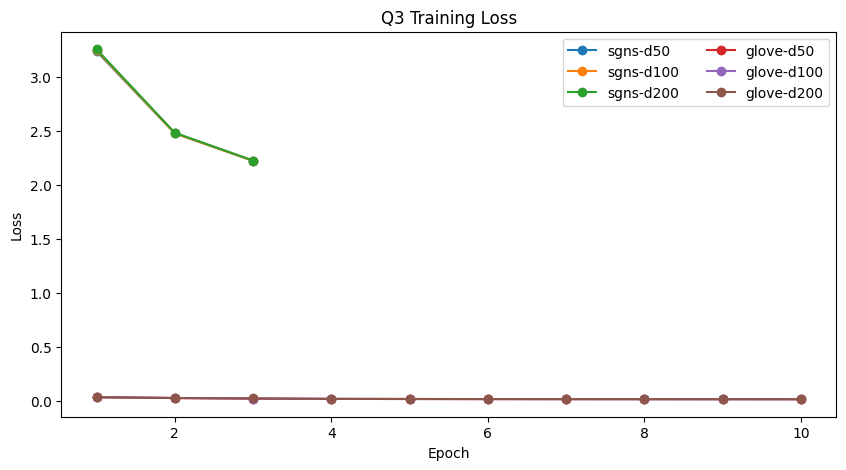

In [6]:
q3_path = RESULTS_DIR / 'q3_summary.json'
q3_loss_table_path = RESULTS_DIR / 'q3_loss_table.csv'
if q3_path.exists():
    q3_summary = json.loads(q3_path.read_text(encoding = 'utf-8'))
    print('Loaded cached Q3 results from', q3_path)
else:
    corpus_path = Path('Assignments/assignment01/data/wiki_corpus.txt')
    tokenized = read_corpus(str(corpus_path), max_lines = 7000)
    token_to_idx, idx_to_token, counts = build_vocab(tokenized, min_count = 5)
    corpus_ids = corpus_to_ids(tokenized, token_to_idx)
    cooc = glove_build_cooccurrence(corpus_ids, window_size = 5, max_cooc = 250000)
    query_words = ['Australia', 'YMCA', 'South', 'building']
    dims = [50, 100, 200]
    q3_summary = {
        'num_sentences': len(tokenized),
        'vocab_size': len(idx_to_token),
        'cooc_size': len(cooc),
        'dims': {}
    }
    rows = []
    for dim in tqdm(dims, desc = 'Q3 dimensions'):
        sgns_out = sgns_train_numpy(corpus_ids, counts, len(idx_to_token), embedding_dim = dim, window_size = 5, negative_samples = 5, epochs = 3, lr = 0.02, max_pairs = 100000, seed = 42)
        glove_out = glove_train_numpy(cooc, len(idx_to_token), embedding_dim = dim, epochs = 10, lr = 0.05, x_max = 100.0, alpha = 0.75, seed = 42)
        q3_summary['dims'][str(dim)] = {
            'sgns_losses': sgns_out['losses'],
            'glove_losses': glove_out['losses'],
            'neighbors': {}
        }
        for w in tqdm(query_words, desc = f'neighbors@d{dim}', leave = False):
            s_nb = nearest_neighbors(w, 8, token_to_idx, idx_to_token, sgns_out['embeddings'])
            g_nb = nearest_neighbors(w, 8, token_to_idx, idx_to_token, glove_out['embeddings'])
            q3_summary['dims'][str(dim)]['neighbors'][w] = {'sgns': s_nb, 'glove': g_nb}
        for ep, value in enumerate(sgns_out['losses'], start = 1):
            rows.append({'model': 'sgns', 'dim': dim, 'epoch': ep, 'loss': value})
        for ep, value in enumerate(glove_out['losses'], start = 1):
            rows.append({'model': 'glove', 'dim': dim, 'epoch': ep, 'loss': value})
    q3_path.write_text(json.dumps(q3_summary, ensure_ascii = False, indent = 2), encoding = 'utf-8')
    pd.DataFrame(rows).to_csv(q3_loss_table_path, index = False)
    print('Trained Q3 and saved results to', q3_path)

dim = '100'
neighbor_rows = []
for w, item in q3_summary['dims'][dim]['neighbors'].items():
    neighbor_rows.append({'word': w, 'model': 'sgns', 'top5': ', '.join([x[0] for x in item['sgns'][:5]])})
    neighbor_rows.append({'word': w, 'model': 'glove', 'top5': ', '.join([x[0] for x in item['glove'][:5]])})
display(pd.DataFrame(neighbor_rows))

plt.figure(figsize = (10, 5))
for model in ['sgns', 'glove']:
    for dim in ['50', '100', '200']:
        ys = q3_summary['dims'][dim][f'{model}_losses']
        xs = list(range(1, len(ys) + 1))
        plt.plot(xs, ys, marker = 'o', label = f'{model}-d{dim}')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Q3 Training Loss')
plt.legend(ncol = 2)
plt.show()

**Q3 conclusion**
- Both SGNS and GloVe reduce training loss, which indicates they capture corpus-level distributional signals.
- Neighbor inspection for `Australia`, `YMCA`, `South`, and `building` shows partial semantic relevance, but also frequent high-frequency or topical noise.
- Increasing dimension from 50 to 200 improves optimization fit, but nearest-neighbor quality does not improve proportionally, which matches the usual capacity-vs-noise tradeoff.

## Question 4 (20 marks)

Space tokenization is problematic for contractions, URLs/emails, and numbers with units.
- `don't` mixes negation with verb form.
- `user@email.com` contains separators that are part of the token itself.
- `3.14km` packs numeric value and unit into one surface form.
The next cells implement BPE and then apply load-or-train behavior for results.

In [7]:
class BPETokenizer:
    def __init__(self):
        self.base_vocab = set()
        self.vocab = set()
        self.merges = []

    def _pair_counts(self, word_symbols_freq):
        pair_counts = defaultdict(int)
        for symbols, freq in word_symbols_freq:
            for i in range(len(symbols) - 1):
                pair_counts[(symbols[i], symbols[i + 1])] += freq
        return pair_counts

    def _merge_once(self, symbols, pair):
        merged = []
        i = 0
        while i < len(symbols):
            if i < len(symbols) - 1 and (symbols[i], symbols[i + 1]) == pair:
                merged.append(symbols[i] + symbols[i + 1])
                i += 2
            else:
                merged.append(symbols[i])
                i += 1
        return merged

    def fit(self, word_freq_dict, vocab_size = 16):
        self.base_vocab = set()
        for w in word_freq_dict:
            self.base_vocab.update(list(w))
        self.vocab = set(self.base_vocab)
        self.merges = []
        ws = [(list(w), f) for w, f in word_freq_dict.items()]
        history = []
        while len(self.vocab) < vocab_size:
            pair_counts = self._pair_counts(ws)
            if not pair_counts:
                break
            pair, cnt = max(pair_counts.items(), key = lambda x: x[1])
            new_token = pair[0] + pair[1]
            self.merges.append(pair)
            self.vocab.add(new_token)
            ws = [(self._merge_once(s, pair), f) for s, f in ws]
            history.append({'merge': f'{pair[0]} + {pair[1]} -> {new_token}', 'count': cnt, 'vocab_size': len(self.vocab)})
        return history

    def tokenize_word(self, word):
        if any(ch not in self.base_vocab for ch in word):
            return ['[unk]']
        symbols = list(word)
        for pair in self.merges:
            symbols = self._merge_once(symbols, pair)
        return symbols

In [8]:
q4_path = RESULTS_DIR / 'q4_bpe_results.json'
if q4_path.exists():
    q4_results = json.loads(q4_path.read_text(encoding = 'utf-8'))
    print('Loaded cached Q4 results from', q4_path)
else:
    wf = {'old': 10, 'older': 5, 'oldest': 8, 'hug': 8, 'pug': 4, 'hugs': 5}
    bpe = BPETokenizer()
    history = bpe.fit(wf, vocab_size = 16)
    targets = ['hold', 'oldest', 'older', 'pug', 'mug', 'huggingface']
    tokens = {w: bpe.tokenize_word(w) for w in targets}
    q4_results = {
        'base_vocab_size': len(bpe.base_vocab),
        'target_vocab_size': 16,
        'final_vocab_size': len(bpe.vocab),
        'merge_history': history,
        'tokens': tokens
    }
    q4_path.write_text(json.dumps(q4_results, ensure_ascii = False, indent = 2), encoding = 'utf-8')
    print('Trained Q4 BPE and saved results to', q4_path)

display(pd.DataFrame(q4_results['merge_history']))
display(pd.DataFrame([{'word': k, 'tokens': ' '.join(v)} for k, v in q4_results['tokens'].items()]))

Loaded cached Q4 results from results/q4_bpe_results.json


,merge,count,vocab_size
0,o + l -> ol,23,12
1,ol + d -> old,23,13
2,u + g -> ug,17,14
3,old + e -> olde,13,15
4,h + ug -> hug,13,16


,word,tokens
0,hold,h old
1,oldest,olde s t
2,older,olde r
3,pug,p ug
4,mug,[unk]
5,huggingface,[unk]


`mug` and `huggingface` are `[unk]` in this toy setup because they include characters outside the base vocabulary.